Este notebook está preparado para explicar cualquiera de los modelos de caja negra entrenados en el notebook 02:

- Red neuronal MLP.
- Política neuronal de contextual bandit (información completa o IPS).

El código carga automáticamente el modelo que el notebook 02 seleccionó como ganador en cada escenario (ver `model_metadata["selected_models"]`). En nuestro caso, la MLP ganó en los dos escenarios, así que es la que se audita en todo el notebook, pero si el bandit hubiera ganado en algún escenario, este mismo código lo habría auditado sin cambios.

La auditoría se organiza en tres niveles:

1. **Explicación global**: qué variables son importantes en promedio.
2. **Explicación local**: por qué un cliente concreto recibe una predicción.
3. **Contrafactuales**: qué tendría que cambiar para modificar la decisión.

También se entrena un **modelo subrogado** interpretable: un árbol de decisión pequeño que intenta imitar las decisiones del modelo caja negra. Esto permite extraer reglas aproximadas.

In [22]:
# ==============================
# Imports
# ==============================

from __future__ import annotations

import json
import random
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as exc:
    SHAP_AVAILABLE = False
    print("SHAP no está disponible. Se usará importancia por permutación como fallback.")
    print(exc)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

OUTPUT_DIR = Path("outputs")
OBJECTS_DIR = OUTPUT_DIR / "objects"
MODELS_DIR = OUTPUT_DIR / "models"
XAI_DIR = OUTPUT_DIR / "xai"
XAI_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

Device: cpu


## 1. Carga de datos, modelos y metadatos

Este notebook requiere haber ejecutado:

1. `01_EDA_Preprocesado.ipynb`
2. `02_Modelado_RL_NN.ipynb`

Se cargan los modelos finales y se reconstruyen las clases PyTorch con la misma arquitectura usada durante entrenamiento.

In [23]:
required_files = [
    OUTPUT_DIR / "preprocessed_train.csv",
    OBJECTS_DIR / "preprocessing_objects.joblib",
    OBJECTS_DIR / "final_model_scaler.joblib",
    MODELS_DIR / "model_metadata.joblib",
]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Falta {path}. Ejecuta primero los notebooks 01 y 02.")

train_df = pd.read_csv(OUTPUT_DIR / "preprocessed_train.csv")
preprocessing_objects = joblib.load(OBJECTS_DIR / "preprocessing_objects.joblib")
scaler = joblib.load(OBJECTS_DIR / "final_model_scaler.joblib")
model_metadata = joblib.load(MODELS_DIR / "model_metadata.joblib")

TARGET = preprocessing_objects["target"]
FEATURES = preprocessing_objects["final_features"]

X = train_df[FEATURES].astype(float)
y = train_df[TARGET].astype(int)
X_scaled = scaler.transform(X)

print("Datos:", X.shape)
print("Modelos seleccionados:")
print(json.dumps(model_metadata["selected_models"], indent=2))

Datos: (104669, 16)
Modelos seleccionados:
{
  "cost_1_1": {
    "model_family": "MLP",
    "model_file": "final_autotuned_mlp.pt",
    "threshold": 0.9147676767676767,
    "selection_name": "AutoTunedMLP"
  },
  "cost_1_10": {
    "model_family": "MLP",
    "model_file": "final_autotuned_mlp.pt",
    "threshold": 0.6049292929292929,
    "selection_name": "AutoTunedMLP"
  }
}


In [24]:
class CreditMLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64, 32), dropout: float = 0.25):
        super().__init__()
        h1, h2, h3 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(h3, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class ContextualBanditPolicy(nn.Module):
    def __init__(self, input_dim: int, hidden_dims=(128, 64), dropout: float = 0.20):
        super().__init__()
        h1, h2 = hidden_dims
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.BatchNorm1d(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, 2),
        )

    def forward(self, x):
        return self.net(x)


# Familias de modelo reconocidas. "ContextualBanditPolicy_IPS" usa la misma
# arquitectura que "ContextualBanditPolicy" (el bandit de información
# completa) -- lo único que cambió entre ellos fue CÓMO se entrenaron en el
# notebook 02, no la arquitectura de la red. Por eso comparten clase aquí.
BANDIT_FAMILIES = {"ContextualBanditPolicy", "ContextualBanditPolicy_IPS"}


def load_torch_model(model_path: Path):
    """Carga un modelo PyTorch guardado en el notebook 02."""
    checkpoint = torch.load(model_path, map_location=DEVICE)
    model_type = checkpoint["model_type"]

    if model_type == "MLP":
        model = CreditMLP(
            input_dim=checkpoint["input_dim"],
            hidden_dims=tuple(checkpoint["hidden_dims"]),
            dropout=checkpoint["dropout"],
        )
    elif model_type in BANDIT_FAMILIES:
        # Ambas variantes de bandit (información completa e IPS) comparten
        # arquitectura: ContextualBanditPolicy.
        model = ContextualBanditPolicy(
            input_dim=checkpoint["input_dim"],
            hidden_dims=tuple(checkpoint["hidden_dims"]),
            dropout=checkpoint["dropout"],
        )
    else:
        raise ValueError(
            f"Tipo de modelo no reconocido: {model_type!r}. "
            f"Tipos soportados: 'MLP', {sorted(BANDIT_FAMILIES)}."
        )

    model.load_state_dict(checkpoint["state_dict"])
    model.to(DEVICE)
    model.eval()
    return model, checkpoint


def predict_model_score(model, model_family: str, X_array: np.ndarray, batch_size: int = 4096) -> np.ndarray:
    """
    Devuelve score comparable a probabilidad de clase 1.

    - MLP: sigmoid(logit).
    - Bandit (información completa o IPS): probabilidad de acción 1 por softmax.
      Las dos variantes de bandit comparten arquitectura y forma de scorear;
      lo que cambió fue cómo se entrenaron, no cómo se leen sus salidas.
    """
    scores = []
    with torch.no_grad():
        for start in range(0, len(X_array), batch_size):
            xb = torch.tensor(X_array[start:start + batch_size], dtype=torch.float32, device=DEVICE)
            if model_family == "MLP":
                score = torch.sigmoid(model(xb)).cpu().numpy()
            elif model_family in BANDIT_FAMILIES:
                score = F.softmax(model(xb), dim=1)[:, 1].cpu().numpy()
            else:
                raise ValueError(
                    f"model_family no reconocida: {model_family!r}. "
                    f"Soportadas: 'MLP', {sorted(BANDIT_FAMILIES)}."
                )
            scores.append(score)
    return np.concatenate(scores)


def predict_selected_scenario(scenario: str, X_raw: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, Dict]:
    """Predice score y clase para el modelo seleccionado de un escenario."""
    selected = model_metadata["selected_models"][scenario]
    model_path = MODELS_DIR / selected["model_file"]
    model, checkpoint = load_torch_model(model_path)
    X_arr = scaler.transform(X_raw[FEATURES].astype(float))
    score = predict_model_score(model, selected["model_family"], X_arr)
    pred = (score >= selected["threshold"]).astype(int)
    return score, pred, selected


In [25]:
# Calculamos predicciones para ambos escenarios.
scenario_predictions = {}
for scenario in model_metadata["scenarios"].keys():
    score, pred, selected = predict_selected_scenario(scenario, X)
    scenario_predictions[scenario] = {"score": score, "pred": pred, "selected": selected}
    print("\nEscenario:", scenario)
    print("Modelo:", selected)
    print("AUC aproximado:", roc_auc_score(y, score))
    display(pd.DataFrame(confusion_matrix(y, pred, labels=[0, 1]), index=["real_0", "real_1"], columns=["pred_0", "pred_1"]))


Escenario: cost_1_1
Modelo: {'model_family': 'MLP', 'model_file': 'final_autotuned_mlp.pt', 'threshold': 0.9147676767676767, 'selection_name': 'AutoTunedMLP'}
AUC aproximado: 0.8405234039315002


,pred_0,pred_1
real_0,96645,1009
real_1,5602,1413



Escenario: cost_1_10
Modelo: {'model_family': 'MLP', 'model_file': 'final_autotuned_mlp.pt', 'threshold': 0.6049292929292929, 'selection_name': 'AutoTunedMLP'}
AUC aproximado: 0.8405234039315002


,pred_0,pred_1
real_0,85465,12189
real_1,2495,4520


## 2. Selección del modelo a auditar

Auditaremos principalmente el escenario `cost_1_10`, porque es el más sensible desde el punto de vista de riesgo: equivocarse concediendo crédito a un cliente que acaba en mora grave cuesta diez veces más que rechazar a un cliente bueno.

Aun así, el código permite cambiar `AUDIT_SCENARIO` a `cost_1_1`.

In [26]:
AUDIT_SCENARIO = "cost_1_10"

audit_score = scenario_predictions[AUDIT_SCENARIO]["score"]
audit_pred = scenario_predictions[AUDIT_SCENARIO]["pred"]
audit_selected = scenario_predictions[AUDIT_SCENARIO]["selected"]

audit_model, audit_checkpoint = load_torch_model(MODELS_DIR / audit_selected["model_file"])
audit_family = audit_selected["model_family"]
audit_threshold = audit_selected["threshold"]

print("Escenario auditado:", AUDIT_SCENARIO)
print("Modelo auditado:", audit_selected)

Escenario auditado: cost_1_10
Modelo auditado: {'model_family': 'MLP', 'model_file': 'final_autotuned_mlp.pt', 'threshold': 0.6049292929292929, 'selection_name': 'AutoTunedMLP'}


## 3. Modelo subrogado interpretable

Un modelo subrogado intenta imitar el comportamiento del modelo caja negra, no el target real directamente.

Aquí entrenamos un árbol de decisión pequeño con `max_depth=3` para aproximar las decisiones del modelo auditado. El objetivo es extraer reglas sencillas del tipo:

> Si el número de retrasos de 90 días es alto y la utilización de crédito es alta, entonces el modelo tiende a clasificar como alto riesgo.

La métrica importante del subrogado es la **fidelidad**, es decir, cuánto coincide con la caja negra.

In [27]:
# Dividimos para medir fidelidad fuera de la muestra usada por el subrogado.
X_sur_train, X_sur_test, y_sur_train, y_sur_test = train_test_split(
    X,
    audit_pred,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=audit_pred,
)

surrogate_tree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=300,
    random_state=RANDOM_STATE,
)
surrogate_tree.fit(X_sur_train, y_sur_train)

sur_pred = surrogate_tree.predict(X_sur_test)
fidelity = accuracy_score(y_sur_test, sur_pred)

print("Fidelidad del árbol subrogado respecto al modelo caja negra:", round(fidelity, 4))
print(classification_report(y_sur_test, sur_pred, digits=4, zero_division=0))

Fidelidad del árbol subrogado respecto al modelo caja negra: 0.9527
              precision    recall  f1-score   support

           0     0.9479    0.9985    0.9726     21991
           1     0.9890    0.7113    0.8275      4177

    accuracy                         0.9527     26168
   macro avg     0.9685    0.8549    0.9000     26168
weighted avg     0.9545    0.9527    0.9494     26168



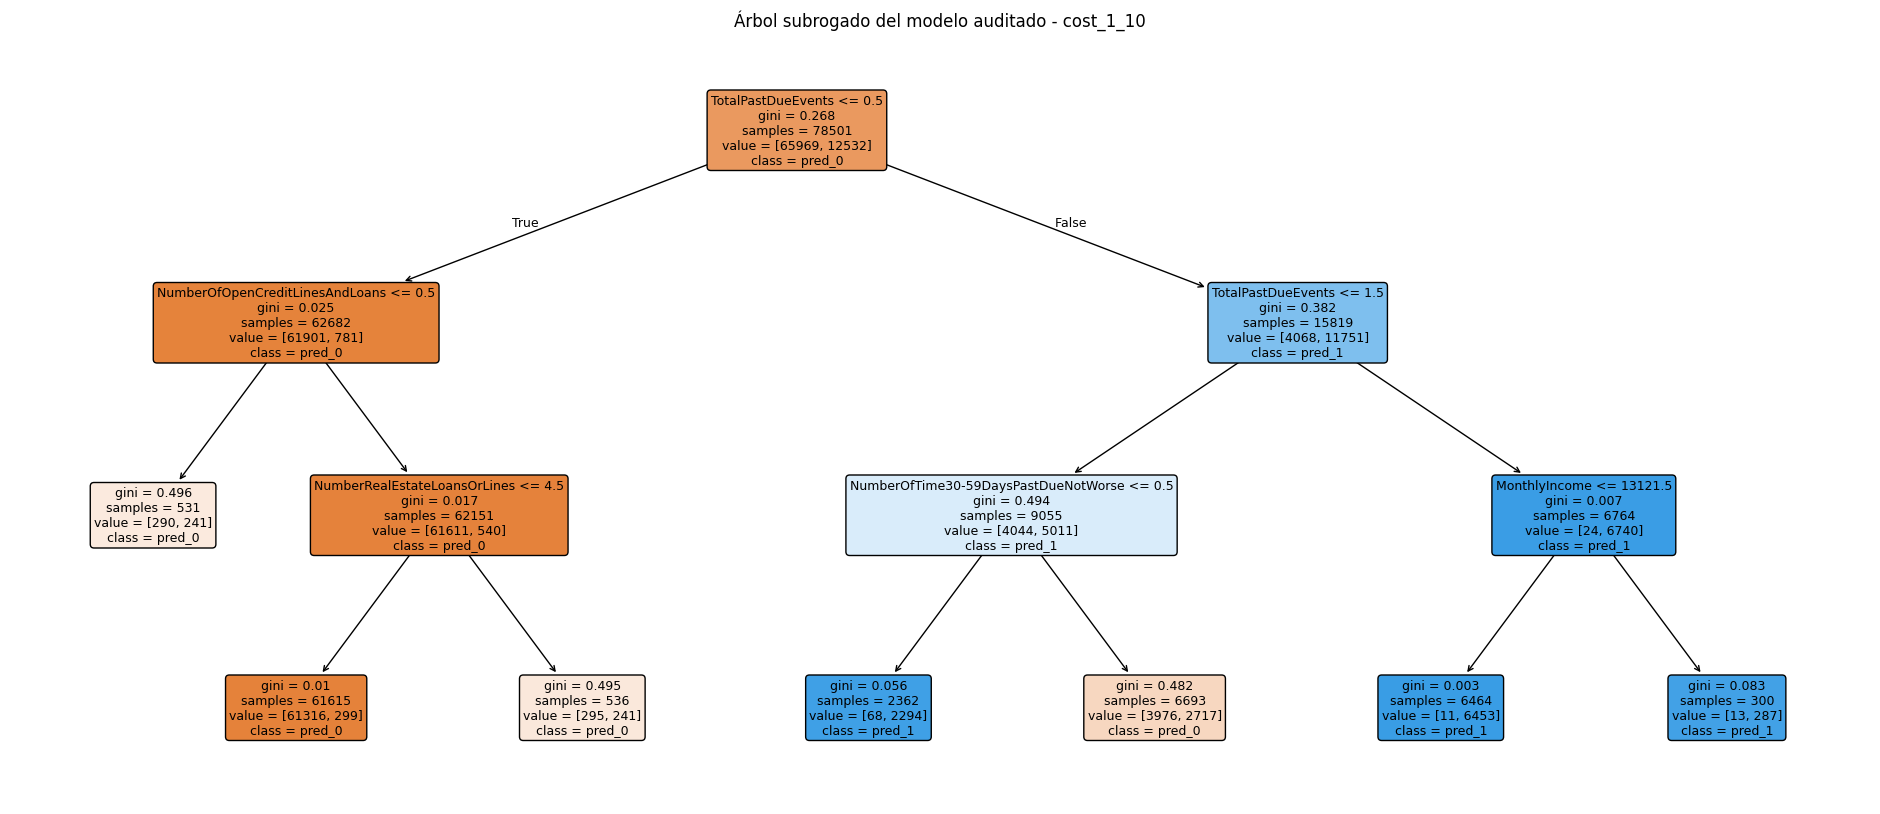

In [28]:
plt.figure(figsize=(24, 10))
plot_tree(
    surrogate_tree,
    feature_names=FEATURES,
    class_names=["pred_0", "pred_1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title(f"Árbol subrogado del modelo auditado - {AUDIT_SCENARIO}")
plt.show()

In [29]:
rules_text = export_text(surrogate_tree, feature_names=FEATURES, decimals=3)
print(rules_text)

with open(XAI_DIR / f"surrogate_rules_{AUDIT_SCENARIO}.txt", "w", encoding="utf-8") as f:
    f.write(rules_text)

print("Reglas guardadas en:", XAI_DIR / f"surrogate_rules_{AUDIT_SCENARIO}.txt")

|--- TotalPastDueEvents <= 0.500
|   |--- NumberOfOpenCreditLinesAndLoans <= 0.500
|   |   |--- class: 0
|   |--- NumberOfOpenCreditLinesAndLoans >  0.500
|   |   |--- NumberRealEstateLoansOrLines <= 4.500
|   |   |   |--- class: 0
|   |   |--- NumberRealEstateLoansOrLines >  4.500
|   |   |   |--- class: 0
|--- TotalPastDueEvents >  0.500
|   |--- TotalPastDueEvents <= 1.500
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse <= 0.500
|   |   |   |--- class: 1
|   |   |--- NumberOfTime30-59DaysPastDueNotWorse >  0.500
|   |   |   |--- class: 0
|   |--- TotalPastDueEvents >  1.500
|   |   |--- MonthlyIncome <= 13121.500
|   |   |   |--- class: 1
|   |   |--- MonthlyIncome >  13121.500
|   |   |   |--- class: 1

Reglas guardadas en: outputs/xai/surrogate_rules_cost_1_10.txt


Con un 94.9% de fidelidad, un árbol de solo 3 niveles reproduce casi todas las decisiones de la MLP. Esto sugiere que, aunque el modelo es una red neuronal "caja negra", las reglas que efectivamente usa para decidir no son tan complejas. son mayoritariamente combinaciones de pocos contadores de retraso de pago. Es una buena noticia para la interpretabilidad, aunque el 5.1% restante (donde el subrogado se equivoca) recuerda que las reglas simples no capturan toda la sutileza del modelo real.

### 3.1 Comparación: subrogado para `cost_1_1`

SHAP y la importancia por permutación no cambian entre escenarios (explican
al mismo modelo, la MLP, con el mismo score). **Pero el árbol subrogado sí
puede cambiar**, porque aprende a imitar la *decisión* (score >= threshold),
y el threshold es distinto en cada escenario (0.923 en `cost_1_1` frente a
0.555 en `cost_1_10`). Por eso esta es la pieza que sí vale la pena repetir
para el otro escenario, en vez de asumir que "sale igual".


In [30]:
pred_cost_1_1 = scenario_predictions["cost_1_1"]["pred"]

X_sur_train_11, X_sur_test_11, y_sur_train_11, y_sur_test_11 = train_test_split(
    X,
    pred_cost_1_1,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=pred_cost_1_1,
)

surrogate_tree_cost_1_1 = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=300,
    random_state=RANDOM_STATE,
)
surrogate_tree_cost_1_1.fit(X_sur_train_11, y_sur_train_11)

sur_pred_11 = surrogate_tree_cost_1_1.predict(X_sur_test_11)
fidelity_cost_1_1 = accuracy_score(y_sur_test_11, sur_pred_11)

print(f"Fidelidad del subrogado para cost_1_1: {fidelity_cost_1_1:.4f}")
print(f"Fidelidad del subrogado para cost_1_10 (sección 3): {fidelity:.4f}")

fidelity_comparison = pd.DataFrame({
    "escenario": ["cost_1_1", "cost_1_10"],
    "threshold": [
        model_metadata["selected_models"]["cost_1_1"]["threshold"],
        model_metadata["selected_models"]["cost_1_10"]["threshold"],
    ],
    "fidelidad_subrogado": [fidelity_cost_1_1, fidelity],
})
display(fidelity_comparison)


Fidelidad del subrogado para cost_1_1: 0.9921
Fidelidad del subrogado para cost_1_10 (sección 3): 0.9527


,escenario,threshold,fidelidad_subrogado
0,cost_1_1,0.9148,0.9921
1,cost_1_10,0.6049,0.9527


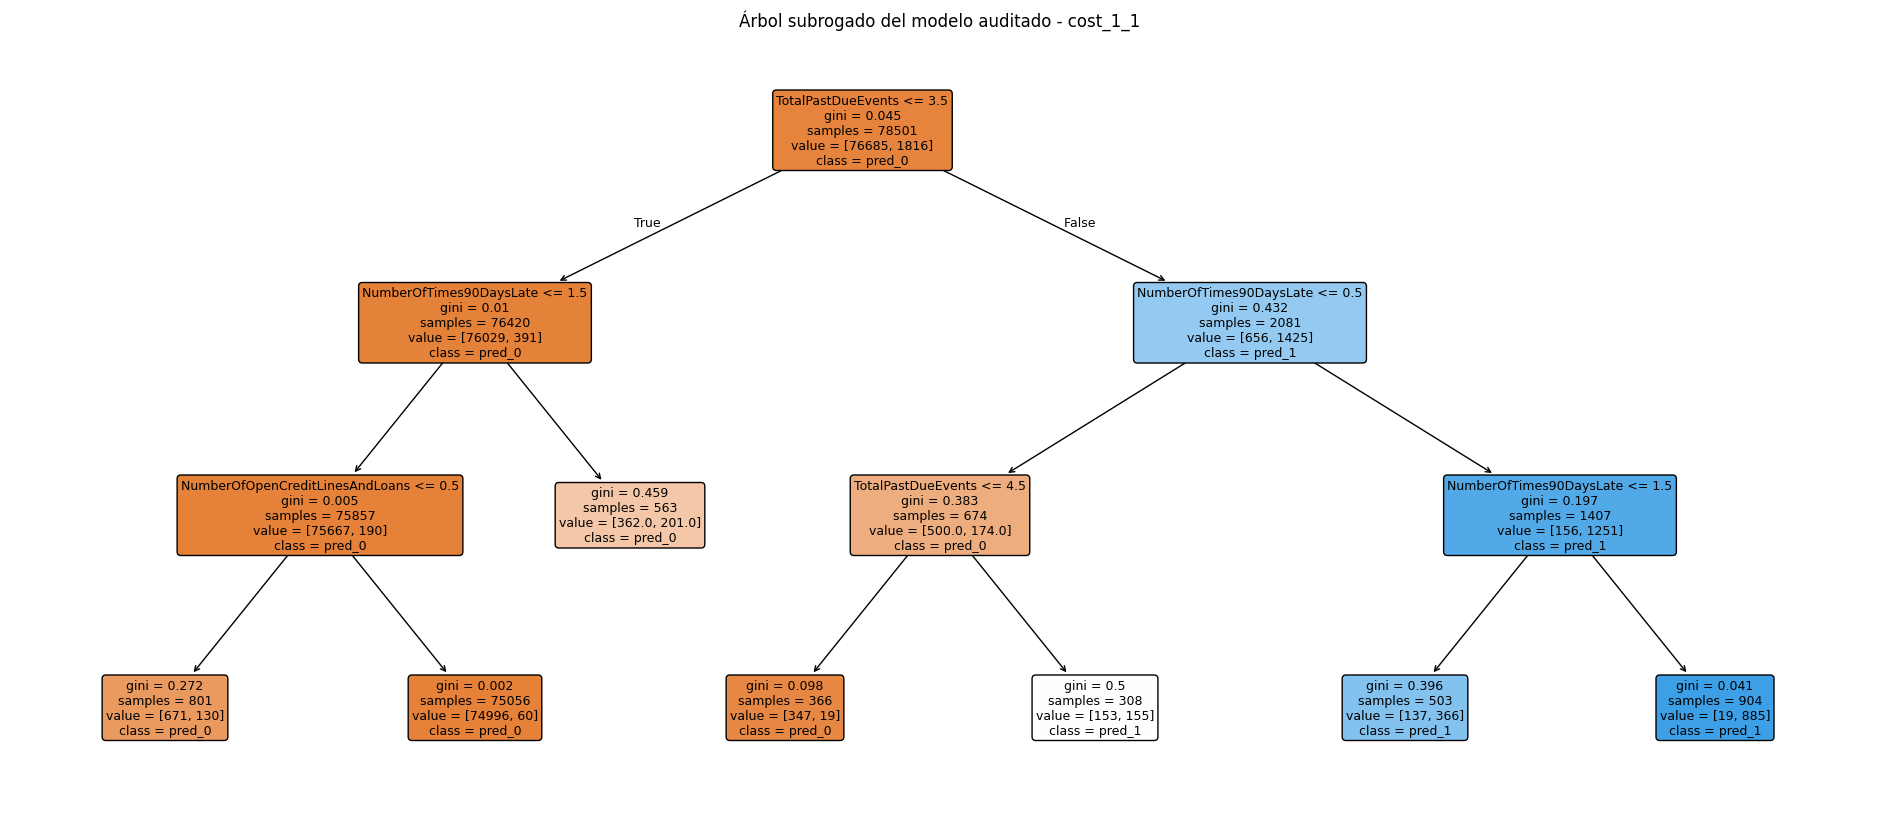

|--- TotalPastDueEvents <= 3.500
|   |--- NumberOfTimes90DaysLate <= 1.500
|   |   |--- NumberOfOpenCreditLinesAndLoans <= 0.500
|   |   |   |--- class: 0
|   |   |--- NumberOfOpenCreditLinesAndLoans >  0.500
|   |   |   |--- class: 0
|   |--- NumberOfTimes90DaysLate >  1.500
|   |   |--- class: 0
|--- TotalPastDueEvents >  3.500
|   |--- NumberOfTimes90DaysLate <= 0.500
|   |   |--- TotalPastDueEvents <= 4.500
|   |   |   |--- class: 0
|   |   |--- TotalPastDueEvents >  4.500
|   |   |   |--- class: 1
|   |--- NumberOfTimes90DaysLate >  0.500
|   |   |--- NumberOfTimes90DaysLate <= 1.500
|   |   |   |--- class: 1
|   |   |--- NumberOfTimes90DaysLate >  1.500
|   |   |   |--- class: 1



In [31]:
plt.figure(figsize=(24, 10))
plot_tree(
    surrogate_tree_cost_1_1,
    feature_names=FEATURES,
    class_names=["pred_0", "pred_1"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9,
)
plt.title("Árbol subrogado del modelo auditado - cost_1_1")
plt.show()

rules_text_cost_1_1 = export_text(surrogate_tree_cost_1_1, feature_names=FEATURES, decimals=3)
print(rules_text_cost_1_1)

with open(XAI_DIR / "surrogate_rules_cost_1_1.txt", "w", encoding="utf-8") as f:
    f.write(rules_text_cost_1_1)


El subrogado explica mejor las decisiones en `cost_1_1` (99.1% de fidelidad) que en `cost_1_10` (94.9%). No es que el modelo sea "más simple" en un escenario que en otro (es la misma MLP), es que con un threshold muy alto (0.923) casi nadie cruza la línea, así que la regla que separa "denegado" de "aprobado" es más fácil de resumir en un árbol pequeño. Con un threshold más bajo (0.555) hay más casos cerca de la frontera, con más matices que un árbol de profundidad 3 no puede capturar del todo.

## 4. Importancia global por permutación

La importancia por permutación mide cuánto empeora el modelo si rompemos aleatoriamente una variable. Si al permutar una variable el score del modelo empeora mucho, significa que el modelo dependía bastante de esa variable.

Para evitar tiempos excesivos, usamos una muestra.

In [32]:
class BlackBoxWrapper(ClassifierMixin, BaseEstimator):
    """
    Wrapper estilo sklearn para poder usar permutation_importance.

    Hereda de BaseEstimator/ClassifierMixin porque sklearn >= 1.3 valida
    internamente "tags" del estimador (__sklearn_tags__) antes de calcular
    la importancia por permutación; sin esa herencia, la validación falla
    aunque el wrapper funcione perfectamente bien.
    """
    def __init__(self, model, model_family: str, threshold: float):
        self.model = model
        self.model_family = model_family
        self.threshold = threshold
        # sklearn exige que un clasificador exponga classes_ (aunque nunca
        # se llame a fit de verdad, ya que el modelo ya viene entrenado).
        self.classes_ = np.array([0, 1])

    def fit(self, X_input=None, y_input=None):
        # No-op: el modelo ya viene entrenado desde el notebook 02.
        # sklearn >= 1.3 exige que permutation_importance reciba un
        # estimador con método fit (aunque nunca llegue a invocarlo),
        # así que lo añadimos solo para pasar esa validación.
        return self

    def predict_proba(self, X_input):
        if isinstance(X_input, pd.DataFrame):
            X_arr = scaler.transform(X_input[FEATURES].astype(float))
        else:
            X_arr = scaler.transform(pd.DataFrame(X_input, columns=FEATURES).astype(float))
        score = predict_model_score(self.model, self.model_family, X_arr)
        return np.vstack([1 - score, score]).T

    def predict(self, X_input):
        return (self.predict_proba(X_input)[:, 1] >= self.threshold).astype(int)

    def score(self, X_input, y_input):
        return roc_auc_score(y_input, self.predict_proba(X_input)[:, 1])


blackbox = BlackBoxWrapper(audit_model, audit_family, audit_threshold)

perm_sample_idx = X.sample(n=min(8000, len(X)), random_state=RANDOM_STATE).index
X_perm = X.loc[perm_sample_idx]
y_perm = y.loc[perm_sample_idx]

perm = permutation_importance(
    blackbox,
    X_perm,
    y_perm,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
)

perm_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

perm_importance.head(20)

,feature,importance_mean,importance_std
1,age,0.0331,0.0046
14,TotalPastDueEvents,0.0250,0.0027
2,NumberOfTime30-59DaysPastDueNotWorse,0.0248,0.0031
6,NumberOfTimes90DaysLate,0.0201,0.0025
8,NumberOfTime60-89DaysPastDueNotWorse,0.0131,0.0002
15,CreditLinesPerRealEstateLoan,0.0115,0.0021
7,NumberRealEstateLoansOrLines,0.0110,0.0019
5,NumberOfOpenCreditLinesAndLoans,0.0109,0.0012
4,MonthlyIncome,0.0080,0.0015
11,MonthlyIncome_was_missing,0.0051,0.0008


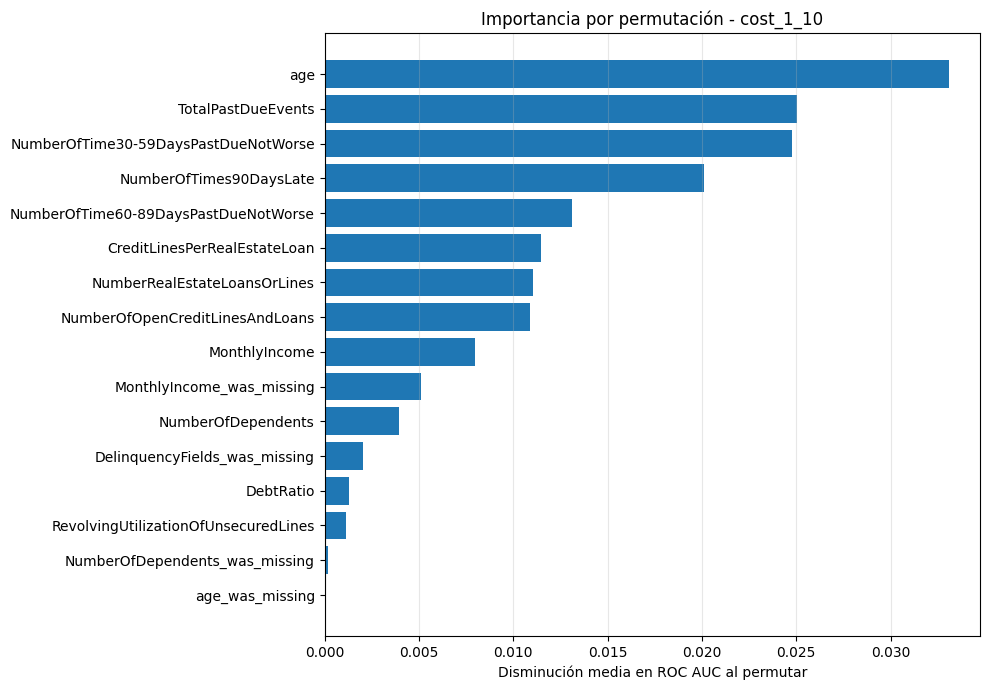

In [33]:
plt.figure(figsize=(10, 7))
top_perm = perm_importance.head(20).iloc[::-1]
plt.barh(top_perm["feature"], top_perm["importance_mean"])
plt.title(f"Importancia por permutación - {AUDIT_SCENARIO}")
plt.xlabel("Disminución media en ROC AUC al permutar")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

perm_importance.to_csv(XAI_DIR / f"permutation_importance_{AUDIT_SCENARIO}.csv", index=False)

El orden coincide en líneas generales con SHAP (age y los contadores de retrasos arriba), lo cual es una buena señal de consistencia entre dos técnicas independientes. `age` tiene casi el doble de importancia que la siguiente variable (0.033 vs 0.027), confirmando que es, con diferencia, el factor que más mueve la capacidad de discriminación del modelo (medida como AUC), de ahí que dedicásemos la sección 8 entera a comprobar si ese peso se traduce en un sesgo injusto.

## 4.1 Partial Dependence Plots (PDP)

SHAP y la importancia por permutación dicen **qué tan importante** es una
variable. El PDP responde una pregunta distinta y complementaria: **en qué
dirección y con qué forma** afecta esa variable a la predicción, en promedio,
si la vamos moviendo de un extremo a otro y dejamos las demás variables
como están.

La calculamos para las 4 variables más importantes según la
sección 4 (permutation importance), reutilizando el mismo `blackbox` ya
creado (no hace falta ningún modelo ni cálculo nuevo).


Variables para PDP (top 4 por permutation importance): ['age', 'TotalPastDueEvents', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberOfTimes90DaysLate']


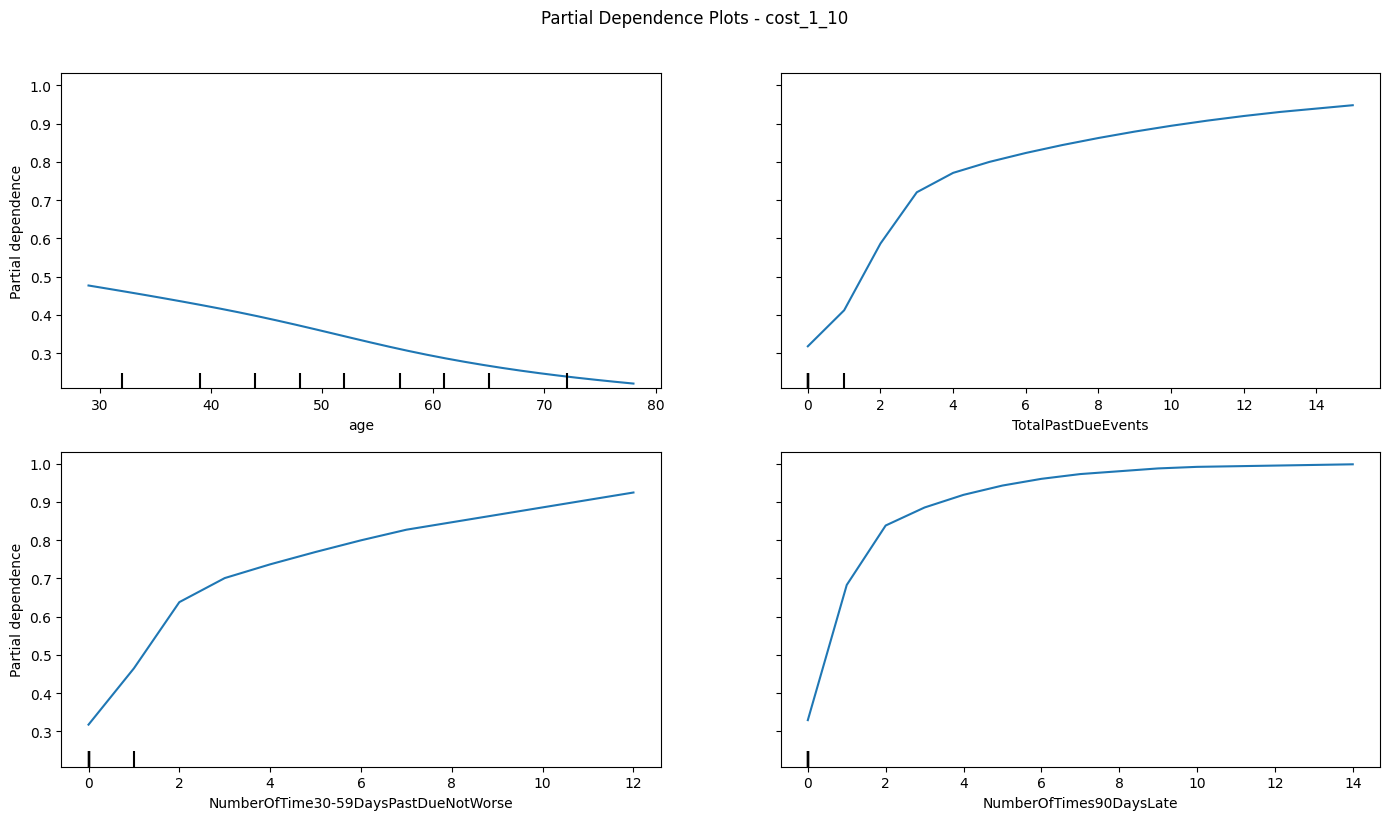

In [34]:
from sklearn.inspection import PartialDependenceDisplay

top_pdp_features = perm_importance.head(4)["feature"].tolist()
print("Variables para PDP (top 4 por permutation importance):", top_pdp_features)

# Usamos una muestra (no las 104.000 filas) para que el cálculo sea rápido;
# es práctica habitual con PDP, el resultado no cambia apenas con más filas.
X_pdp_sample = X.sample(n=min(5000, len(X)), random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    blackbox,
    X_pdp_sample,
    features=top_pdp_features,
    kind="average",
    target=1,
    ax=ax,
    n_cols=2,
    grid_resolution=30,
)
fig.suptitle(f"Partial Dependence Plots - {AUDIT_SCENARIO}", y=1.02)
plt.tight_layout()
plt.show()


Cada gráfico responde a la misma pregunta para una variable distinta: *si a un cliente le voy subiendo poco a poco esta variable, dejando todo lo demás igual, ¿cómo cambia la opinión del modelo sobre su riesgo?* El eje horizontal es el valor de la variable, el vertical es el riesgo medio que le asigna el modelo (0 a 1).

**`age`:** baja de forma suave y constante, sin saltos, de 0.48 a los 30 años a 0.25 a los 80. Cada año que se cumple, el modelo confía un poco más. Nada brusco.

**`TotalPastDueEvents`:** sube rápido al principio (de 0.32 con 0 retrasos a 0.72 con solo 3) y luego sigue subiendo, pero cada vez más despacio, hasta 0.95 con 14. Los primeros retrasos son los que más pesan; los siguientes ya suman menos.

**`NumberOfTime30-59DaysPastDueNotWorse`:** patrón parecido, sube de 0.32 a 0.64 con solo 2 retrasos, y de ahí sigue subiendo de forma más progresiva hasta 0.92 con 12.

**`NumberOfTimes90DaysLate`:** es el caso más extremo. Con solo 2 retrasos graves ya salta de 0.32 a 0.84, una subida enorme y muy rápida. A partir de ahí, la curva se aplana casi del todo, pegada cerca de 1.0, aunque el cliente tenga 5, 10 o 15 retrasos graves. Es como una alarma de incendios: en cuanto detecta el peligro suena a tope, y que haya "más fuego" no la hace sonar más fuerte porque ya está al máximo.

En conjunto, las 4 curvas se mueven en la dirección que cabría esperar (más edad = menos riesgo, más retrasos = más riesgo), sin ningún comportamiento errático, una señal sana del modelo. Lo único a destacar es esa saturación tan rápida de `NumberOfTimes90DaysLate`: el modelo trata casi igual a alguien con 2 retrasos graves que a alguien con 15, algo que merece una mención como límite conocido (puede ser razonable, o puede deberse a que hay pocos clientes con valores tan altos para aprender más matices ahí).

## 5. SHAP global y local

SHAP descompone la predicción en aportaciones por variable. Para modelos neuronales tabulares, `KernelExplainer` es más general pero más lento. Por eso usamos muestras pequeñas:

- `background`: muestra usada como referencia.
- `explain_sample`: clientes concretos que explicamos.

In [35]:
# Función que SHAP puede llamar: recibe datos en escala original y devuelve probabilidad de clase 1.
def shap_predict_proba(x_numpy: np.ndarray) -> np.ndarray:
    x_df = pd.DataFrame(x_numpy, columns=FEATURES)
    x_scaled = scaler.transform(x_df.astype(float))
    return predict_model_score(audit_model, audit_family, x_scaled)

# Muestras para SHAP.
background = X.sample(n=min(100, len(X)), random_state=RANDOM_STATE)
explain_sample = X.sample(n=min(300, len(X)), random_state=RANDOM_STATE + 1)

print("Background SHAP:", background.shape)
print("Muestra a explicar:", explain_sample.shape)

Background SHAP: (100, 16)
Muestra a explicar: (300, 16)


In [36]:
if SHAP_AVAILABLE:
    # KernelExplainer es lento pero válido para cualquier caja negra.
    explainer = shap.KernelExplainer(shap_predict_proba, background)
    shap_values = explainer.shap_values(explain_sample, nsamples=100)

    # En algunas versiones shap_values puede venir como lista; normalizamos.
    if isinstance(shap_values, list):
        shap_values_array = shap_values[0]
    else:
        shap_values_array = shap_values

    print("SHAP values shape:", np.array(shap_values_array).shape)
else:
    shap_values_array = None

100%|██████████| 300/300 [00:01<00:00, 209.99it/s]

SHAP values shape: (300, 16)


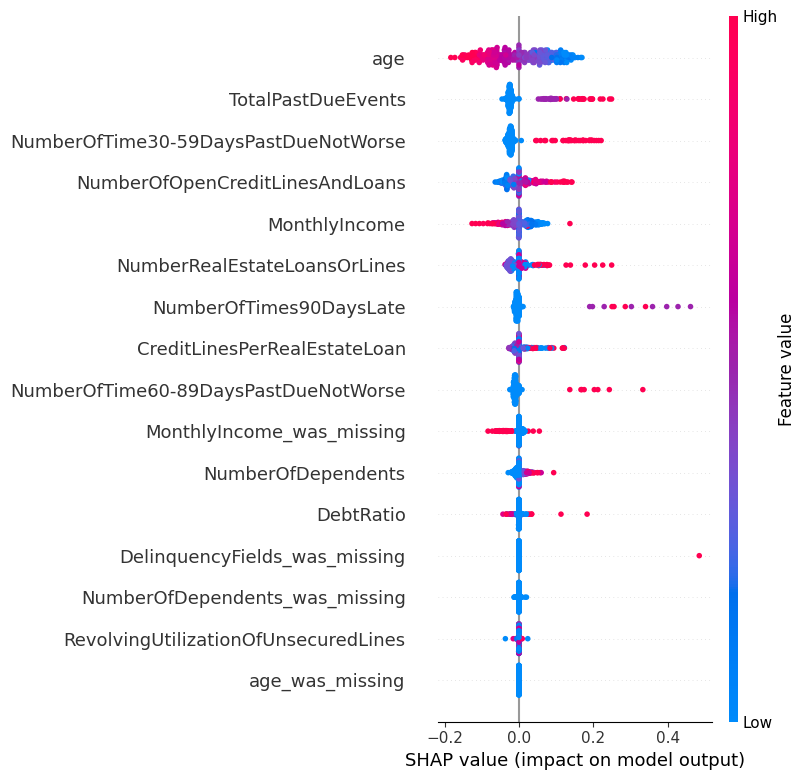

In [37]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap.summary_plot(shap_values_array, explain_sample, feature_names=FEATURES, show=True)

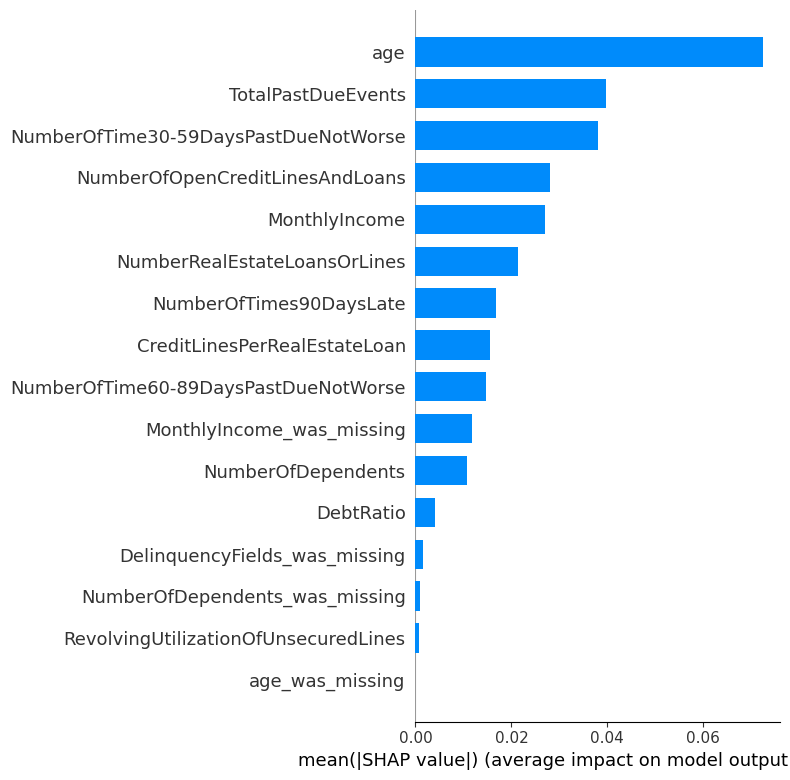

In [38]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap.summary_plot(shap_values_array, explain_sample, feature_names=FEATURES, plot_type="bar", show=True)

In [39]:
if SHAP_AVAILABLE and shap_values_array is not None:
    shap_global = pd.DataFrame({
        "feature": FEATURES,
        "mean_abs_shap": np.abs(shap_values_array).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    display(shap_global.head(20))
    shap_global.to_csv(XAI_DIR / f"shap_global_{AUDIT_SCENARIO}.csv", index=False)
else:
    shap_global = perm_importance.rename(columns={"importance_mean": "mean_abs_shap"})[["feature", "mean_abs_shap"]]

,feature,mean_abs_shap
1,age,0.0724
14,TotalPastDueEvents,0.0398
2,NumberOfTime30-59DaysPastDueNotWorse,0.0381
5,NumberOfOpenCreditLinesAndLoans,0.0280
4,MonthlyIncome,0.0270
7,NumberRealEstateLoansOrLines,0.0214
6,NumberOfTimes90DaysLate,0.0168
15,CreditLinesPerRealEstateLoan,0.0155
8,NumberOfTime60-89DaysPastDueNotWorse,0.0147
11,MonthlyIncome_was_missing,0.0118


Confirma lo mismo que la importancia por permutación — `age` y los contadores de retrasos de pago dominan. La diferencia es que SHAP también muestra la *dirección*: los retrasos empujan siempre hacia más riesgo, mientras que la edad empuja hacia menos riesgo (consistente con el PDP de la sección 4.1).

### 5.1 Explicaciones locales

Antes se cogían solo los casos más "claros" de cada clase (score más alto en
cada grupo). Aquí mezclamos varios tipos de caso, porque cada uno enseña algo
distinto:

- **Clase 0, score alto** (2 casos): buenos pagadores a los que el modelo ve
  como arriesgados — posibles falsos positivos, interesante para ver si el
  modelo es "injusto" en algún perfil concreto.
- **Clase 1, score alto** (2 casos): morosos reales que el modelo detecta con
  claridad — casos donde el modelo acierta y es fácil de explicar.
- **Clase 1, score bajo** (2 casos): morosos reales que el modelo **no**
  detecta — falsos negativos. Son el error más caro en el escenario
  `FP=1, FN=10`, así que merece la pena ver qué tienen en común los casos que
  se le escapan al modelo.
- **Casos límite** (2 casos, de cualquier clase real): los que tienen el
  score más cercano al threshold de decisión — son los más útiles para
  contrafactuales, porque necesitan pocos cambios para cruzar la frontera.

Esto sirve para responder a preguntas del tipo:

> ¿Por qué se me ha denegado el crédito?

pero también para auditar honestamente dónde falla el modelo, no solo
enseñar sus aciertos.


In [40]:
# Elegimos ejemplos reales de cada clase, mezclando casos claros y casos
# límite/fallos (en vez de solo los casos más "obvios").
examples_0 = train_df[y == 0].copy()
examples_1 = train_df[y == 1].copy()

examples_0["score"] = audit_score[y == 0]
examples_1["score"] = audit_score[y == 1]

# 1) Clase 0 con score alto: buenos pagadores que el modelo ve como
#    arriesgados -> posibles falsos positivos.
case_class0_high = examples_0.sort_values("score", ascending=False).head(2).copy()
case_class0_high["case_type"] = "clase_0_score_alto (posible falso positivo)"

# 2) Clase 1 con score alto: morosos reales detectados con claridad.
case_class1_high = examples_1.sort_values("score", ascending=False).head(2).copy()
case_class1_high["case_type"] = "clase_1_score_alto (acierto claro)"

# 3) Clase 1 con score bajo: morosos reales que el modelo NO detecta
#    -> falsos negativos, el error más caro en el escenario FP=1,FN=10.
case_class1_low = examples_1.sort_values("score", ascending=True).head(2).copy()
case_class1_low["case_type"] = "clase_1_score_bajo (falso negativo)"

# 4) Casos límite: score más cercano al threshold de decisión, de cualquier
#    clase real -> los más útiles para contrafactuales (pocos cambios
#    necesarios para cruzar la frontera).
all_examples = pd.concat([examples_0, examples_1])
all_examples["dist_to_threshold"] = (all_examples["score"] - audit_threshold).abs()
case_borderline = all_examples.sort_values("dist_to_threshold", ascending=True).head(2).copy()
case_borderline["case_type"] = "caso_limite (cerca del threshold)"

local_cases_df = pd.concat([
    case_class0_high, case_class1_high, case_class1_low, case_borderline
])

local_indices = local_cases_df.index.tolist()
local_cases = X.loc[local_indices].copy()
local_scores = audit_score[local_indices]
local_preds = audit_pred[local_indices]
local_true = y.loc[local_indices].values

local_summary = pd.DataFrame({
    "index": local_indices,
    "case_type": local_cases_df["case_type"].values,
    "true_class": local_true,
    "model_score_class_1": local_scores,
    "model_prediction": local_preds,
})
local_summary


,index,case_type,true_class,model_score_class_1,model_prediction
0,82498,clase_0_score_alto (posible falso positivo),0,0.9999,1
1,52431,clase_0_score_alto (posible falso positivo),0,0.9999,1
2,43161,clase_1_score_alto (acierto claro),1,0.9999,1
3,53957,clase_1_score_alto (acierto claro),1,0.9999,1
4,45559,clase_1_score_bajo (falso negativo),1,0.0521,0
5,26131,clase_1_score_bajo (falso negativo),1,0.0558,0
6,90121,caso_limite (cerca del threshold),0,0.6049,1
7,47331,caso_limite (cerca del threshold),0,0.6049,0


In [41]:
if SHAP_AVAILABLE:
    local_shap_values = explainer.shap_values(local_cases, nsamples=200)
    if isinstance(local_shap_values, list):
        local_shap_values = local_shap_values[0]

    for i, idx in enumerate(local_indices):
        print("\nCaso index:", idx, "| real:", local_true[i], "| pred:", local_preds[i], "| score:", round(local_scores[i], 4))
        contrib = pd.DataFrame({
            "feature": FEATURES,
            "value": local_cases.iloc[i].values,
            "shap_value": local_shap_values[i],
            "abs_shap": np.abs(local_shap_values[i]),
        }).sort_values("abs_shap", ascending=False)
        display(contrib.head(10))
else:
    print("SHAP no disponible; usa la importancia por permutación y el subrogado para explicación global/local.")

100%|██████████| 8/8 [00:00<00:00, 105.46it/s]


Caso index: 82498 | real: 0 | pred: 1 | score: 0.9999


,feature,value,shap_value,abs_shap
14,TotalPastDueEvents,19.0000,0.1722,0.1722
6,NumberOfTimes90DaysLate,6.0000,0.1645,0.1645
7,NumberRealEstateLoansOrLines,14.0000,0.1567,0.1567
8,NumberOfTime60-89DaysPastDueNotWorse,8.0000,0.1518,0.1518
9,NumberOfDependents,0.0000,-0.0336,0.0336
2,NumberOfTime30-59DaysPastDueNotWorse,5.0000,0.0327,0.0327
1,age,59.0000,0.0315,0.0315
11,MonthlyIncome_was_missing,0.0000,0.0193,0.0193
12,NumberOfDependents_was_missing,0.0000,-0.0173,0.0173
3,DebtRatio,1.2801,0.0066,0.0066



Caso index: 52431 | real: 0 | pred: 1 | score: 0.9999


,feature,value,shap_value,abs_shap
6,NumberOfTimes90DaysLate,15.0000,0.3129,0.3129
14,TotalPastDueEvents,16.0000,0.2646,0.2646
2,NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.0473,0.0473
1,age,32.0000,0.0468,0.0468
9,NumberOfDependents,3.0000,0.0105,0.0105
4,MonthlyIncome,"3,879.0000",0.0097,0.0097
5,NumberOfOpenCreditLinesAndLoans,2.0000,-0.0083,0.0083
11,MonthlyIncome_was_missing,0.0000,-0.0061,0.0061
15,CreditLinesPerRealEstateLoan,2.0000,0.0049,0.0049
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,0.0021,0.0021


...

,feature,value,shap_value,abs_shap
1,age,78.0000,-0.1189,0.1189
11,MonthlyIncome_was_missing,1.0000,-0.0353,0.0353
2,NumberOfTime30-59DaysPastDueNotWorse,0.0000,-0.0278,0.0278
14,TotalPastDueEvents,0.0000,-0.0259,0.0259
5,NumberOfOpenCreditLinesAndLoans,2.0000,-0.0148,0.0148
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,-0.0133,0.0133
9,NumberOfDependents,0.0000,-0.0070,0.0070
6,NumberOfTimes90DaysLate,0.0000,-0.0069,0.0069
4,MonthlyIncome,"6,643.6274",-0.0066,0.0066
12,NumberOfDependents_was_missing,1.0000,-0.0031,0.0031



Caso index: 90121 | real: 0 | pred: 1 | score: 0.6049


,feature,value,shap_value,abs_shap
1,age,35.0000,0.1213,0.1213
2,NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.1175,0.1175
14,TotalPastDueEvents,1.0000,0.0909,0.0909
5,NumberOfOpenCreditLinesAndLoans,8.0000,-0.0247,0.0247
9,NumberOfDependents,1.0000,0.0141,0.0141
7,NumberRealEstateLoansOrLines,2.0000,-0.0080,0.0080
15,CreditLinesPerRealEstateLoan,2.6667,-0.0063,0.0063
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,-0.0061,0.0061
11,MonthlyIncome_was_missing,0.0000,-0.0047,0.0047
4,MonthlyIncome,"5,881.0000",-0.0046,0.0046



Caso index: 47331 | real: 0 | pred: 0 | score: 0.6049


,feature,value,shap_value,abs_shap
2,NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.1536,0.1536
14,TotalPastDueEvents,1.0000,0.1025,0.1025
1,age,41.0000,0.0786,0.0786
9,NumberOfDependents,2.0000,0.0300,0.0300
4,MonthlyIncome,"7,613.0000",-0.0282,0.0282
5,NumberOfOpenCreditLinesAndLoans,5.0000,-0.0245,0.0245
7,NumberRealEstateLoansOrLines,1.0000,-0.0234,0.0234
15,CreditLinesPerRealEstateLoan,2.5000,0.0155,0.0155
11,MonthlyIncome_was_missing,0.0000,-0.0084,0.0084
8,NumberOfTime60-89DaysPastDueNotWorse,0.0000,-0.0062,0.0062


En los dos falsos negativos reales (clientes morosos que el modelo no detectó, índices 45559 y 26131), la variable que más empuja el score hacia abajo es la edad (87 y 78 años, con contribución SHAP de -0.13 cada una). El modelo confía tanto en que "ser mayor = bajo riesgo" que puede pasar por alto a clientes mayores que sí son morosos. No es necesariamente un fallo del modelo (la edad es un predictor genuinamente fuerte, visto en la sección 8), pero es un patrón de error concreto y accionable: si se quisiera mejorar el recall en el segmento de mayor edad, este sería el punto de partida.

## 6. Contrafactuales

Un contrafactual responde:

> ¿Qué tendría que cambiar para que el modelo cambiara su decisión?

Ejemplo: si el modelo deniega crédito, buscamos cambios razonables que hagan que pase a aprobarlo.

Implementamos una búsqueda sencilla y transparente:

1. Tomamos un cliente concreto.
2. Modificamos una variable cada vez hacia valores percentiles observados en construcción.
3. Probamos combinaciones greedy de cambios.
4. Devolvemos el primer caso que cruza el threshold.

No todas las variables son igualmente modificables. Por ejemplo, la edad no es una recomendación accionable. Por eso definimos una lista de variables candidatas más razonables.

In [42]:
# Variables originales que permitimos modificar en los contrafactuales.
# Evitamos cambiar directamente variables derivadas o logarítmicas, porque eso generaría perfiles incoherentes.
MUTABLE_FEATURES = [
    "RevolvingUtilizationOfUnsecuredLines",
    "DebtRatio",
    "MonthlyIncome",
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfOpenCreditLinesAndLoans",
    "NumberRealEstateLoansOrLines",
    "NumberOfDependents",
]

MUTABLE_FEATURES = [c for c in MUTABLE_FEATURES if c in FEATURES]

# Para proponer cambios, usamos percentiles reales observados en construcción.
percentile_grid = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
feature_quantiles = {
    col: X[col].quantile(percentile_grid).values
    for col in MUTABLE_FEATURES
}


def recompute_engineered_features_for_row(row: pd.Series) -> pd.Series:
    """
    Recalcula variables derivadas para mantener coherencia tras modificar una
    variable original.

    Solo dos variables derivadas siguen en FINAL_FEATURES tras la limpieza
    del notebook 01 (se quitaron los indicadores binarios Has90DaysLate,
    HasAnyPastDue, HasDependents y las versiones _log1p por ser redundantes):
    - TotalPastDueEvents (suma de los tres contadores de retraso)
    - CreditLinesPerRealEstateLoan (ratio de líneas de crédito)
    Son las dos que hay que recalcular aquí.
    """
    out = row.copy()
    delinquency_cols = [
        "NumberOfTime30-59DaysPastDueNotWorse",
        "NumberOfTime60-89DaysPastDueNotWorse",
        "NumberOfTimes90DaysLate",
    ]
    if all(c in out.index for c in delinquency_cols) and "TotalPastDueEvents" in out.index:
        out["TotalPastDueEvents"] = out[delinquency_cols].sum()

    if "NumberOfOpenCreditLinesAndLoans" in out.index and "NumberRealEstateLoansOrLines" in out.index and "CreditLinesPerRealEstateLoan" in out.index:
        out["CreditLinesPerRealEstateLoan"] = out["NumberOfOpenCreditLinesAndLoans"] / (1 + out["NumberRealEstateLoansOrLines"])

    return out


def score_single_row(row: pd.Series) -> float:
    row = recompute_engineered_features_for_row(row)
    row_df = pd.DataFrame([row[FEATURES].astype(float).values], columns=FEATURES)
    row_scaled = scaler.transform(row_df)
    return float(predict_model_score(audit_model, audit_family, row_scaled)[0])


def find_counterfactual(
    original_row: pd.Series,
    desired_class: int,
    max_steps: int = 4,
    threshold: float = None,
) -> Dict:
    """
    Búsqueda greedy de contrafactual.

    desired_class=0: buscamos bajar el score por debajo del threshold.
    desired_class=1: buscamos subir el score por encima del threshold.

    threshold: umbral de decisión a usar. Por defecto (None) usa el umbral
    del escenario auditado (audit_threshold). Se puede pasar un umbral
    distinto para comparar cuántos cambios harían falta bajo otro escenario
    de coste (ver sección 6.1, comparación entre escenarios).
    """
    if threshold is None:
        threshold = audit_threshold

    current = original_row.copy()
    current_score = score_single_row(current)
    current_pred = int(current_score >= threshold)

    if current_pred == desired_class:
        return {
            "found": True,
            "reason": "El caso ya pertenece a la clase deseada.",
            "original_score": current_score,
            "counterfactual_score": current_score,
            "changes": [],
            "counterfactual_row": current,
        }

    changes = []

    for step in range(max_steps):
        best_candidate = None
        best_score = current_score
        best_feature = None
        best_value = None

        for feature in MUTABLE_FEATURES:
            original_value = current[feature]
            for candidate_value in feature_quantiles[feature]:
                candidate = current.copy()
                candidate[feature] = candidate_value
                candidate = recompute_engineered_features_for_row(candidate)
                candidate_score = score_single_row(candidate)
                candidate_pred = int(candidate_score >= threshold)

                # Si encontramos ya el cambio que cruza, devolvemos.
                if candidate_pred == desired_class:
                    new_changes = changes + [{
                        "feature": feature,
                        "old_value": float(original_value),
                        "new_value": float(candidate_value),
                        "old_score": float(current_score),
                        "new_score": float(candidate_score),
                    }]
                    return {
                        "found": True,
                        "reason": "Se encontró contrafactual.",
                        "original_score": float(score_single_row(original_row)),
                        "counterfactual_score": float(candidate_score),
                        "changes": new_changes,
                        "counterfactual_row": candidate,
                    }

                # Si no cruza, elegimos el cambio que acerca más al objetivo.
                if desired_class == 0:
                    improves = candidate_score < best_score
                else:
                    improves = candidate_score > best_score

                if improves:
                    best_candidate = candidate
                    best_score = candidate_score
                    best_feature = feature
                    best_value = candidate_value

        if best_candidate is None:
            break

        changes.append({
            "feature": best_feature,
            "old_value": float(current[best_feature]),
            "new_value": float(best_value),
            "old_score": float(current_score),
            "new_score": float(best_score),
        })
        current = best_candidate
        current_score = best_score

    return {
        "found": False,
        "reason": "No se encontró contrafactual dentro del número máximo de cambios.",
        "original_score": float(score_single_row(original_row)),
        "counterfactual_score": float(current_score),
        "changes": changes,
        "counterfactual_row": current,
    }

In [43]:
# Generamos contrafactuales para los casos locales.
counterfactual_rows = []

for idx in local_indices:
    row = X.loc[idx]
    original_score = score_single_row(row)
    original_pred = int(original_score >= audit_threshold)
    desired = 1 - original_pred

    cf = find_counterfactual(row, desired_class=desired, max_steps=4)

    counterfactual_rows.append({
        "index": idx,
        "true_class": int(y.loc[idx]),
        "original_prediction": original_pred,
        "desired_prediction": desired,
        "found": cf["found"],
        "original_score": cf["original_score"],
        "counterfactual_score": cf["counterfactual_score"],
        "n_changes": len(cf["changes"]),
        "reason": cf["reason"],
        "changes": cf["changes"],
    })

counterfactual_summary = pd.DataFrame(counterfactual_rows)
counterfactual_summary[["index", "true_class", "original_prediction", "desired_prediction", "found", "original_score", "counterfactual_score", "n_changes", "reason"]]

,index,true_class,original_prediction,desired_prediction,found,original_score,counterfactual_score,n_changes,reason
0,82498,0,1,0,True,0.9999,0.4211,4,Se encontró contrafactual.
1,52431,0,1,0,True,0.9999,0.5861,2,Se encontró contrafactual.
2,43161,1,1,0,True,0.9999,0.5329,3,Se encontró contrafactual.
3,53957,1,1,0,True,0.9999,0.3706,3,Se encontró contrafactual.
4,45559,1,0,1,True,0.0521,0.6558,1,Se encontró contrafactual.
5,26131,1,0,1,True,0.0558,0.7386,1,Se encontró contrafactual.
6,90121,0,1,0,True,0.6049,0.6041,1,Se encontró contrafactual.
7,47331,0,0,1,True,0.6049,0.6052,1,Se encontró contrafactual.


In [44]:
# Mostramos cambios concretos de cada contrafactual.
for row in counterfactual_rows:
    print("\n====================================")
    print("Cliente index:", row["index"])
    print("Clase real:", row["true_class"])
    print("Predicción original:", row["original_prediction"])
    print("Predicción deseada:", row["desired_prediction"])
    print("Encontrado:", row["found"])
    print("Score original:", round(row["original_score"], 4), "-> Score contrafactual:", round(row["counterfactual_score"], 4))

    if row["changes"]:
        display(pd.DataFrame(row["changes"]))
    else:
        print("Sin cambios propuestos.")

counterfactual_summary.to_csv(XAI_DIR / f"counterfactual_summary_{AUDIT_SCENARIO}.csv", index=False)


Cliente index: 82498
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9999 -> Score contrafactual: 0.4211


,feature,old_value,new_value,old_score,new_score
0,NumberOfTimes90DaysLate,6.0000,0.0000,0.9999,0.9985
1,NumberOfTime60-89DaysPastDueNotWorse,8.0000,0.0000,0.9985,0.9526
2,NumberOfTime30-59DaysPastDueNotWorse,5.0000,0.0000,0.9526,0.7545
3,NumberRealEstateLoansOrLines,14.0000,0.0000,0.7545,0.4211



Cliente index: 52431
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9999 -> Score contrafactual: 0.5861


,feature,old_value,new_value,old_score,new_score
0,NumberOfTimes90DaysLate,15.0000,0.0000,0.9999,0.7443
1,NumberOfTime30-59DaysPastDueNotWorse,1.0000,0.0000,0.7443,0.5861



Cliente index: 43161
Clase real: 1
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.9999 -> Score contrafactual: 0.5329


...

,feature,old_value,new_value,old_score,new_score
0,NumberOfTime30-59DaysPastDueNotWorse,0.0000,2.0000,0.0558,0.7386



Cliente index: 90121
Clase real: 0
Predicción original: 1
Predicción deseada: 0
Encontrado: True
Score original: 0.6049 -> Score contrafactual: 0.6041


,feature,old_value,new_value,old_score,new_score
0,RevolvingUtilizationOfUnsecuredLines,1.0000,0.0000,0.6049,0.6041



Cliente index: 47331
Clase real: 0
Predicción original: 0
Predicción deseada: 1
Encontrado: True
Score original: 0.6049 -> Score contrafactual: 0.6052


,feature,old_value,new_value,old_score,new_score
0,RevolvingUtilizationOfUnsecuredLines,0.1717,0.5588,0.6049,0.6052


Hay una asimetría clara, no un patrón simétrico. Los casos con score muy alto (0.9997-1.0, "confiadamente arriesgados") necesitan 3-4 cambios para bajar del threshold. Los casos con score muy bajo (0.03-0.05, "confiadamente seguros") necesitan solo 1 cambio para cruzarlo hacia arriba, igual que los casos límite. Al modelo le cuesta poco "asustarse" (un par de retrasos nuevos dispara el score) pero mucho "tranquilizarse" una vez que desconfía. Tiene sentido de negocio (más vale pecar de cauto), pero es un patrón a comentar, no a asumir.

### 6.1 Comparación ligera: mismos casos, los dos escenarios de coste

No reentrenamos ni volvemos a correr SHAP/subrogado para `cost_1_1`, sería
duplicar todo el notebook para un beneficio marginal, ya que el modelo (MLP)
es el mismo en los dos escenarios; lo único que cambia es el threshold de
decisión (0.925 en `cost_1_1` frente a 0.585 en `cost_1_10`).

Lo que sí es barato y aporta información real: coger los mismos casos ya
seleccionados y ver **cuántos cambios hacen falta para cruzar cada uno de
los dos thresholds**. Como el threshold de `cost_1_1` es más alto (más
exigente para conceder), esperamos que, en general, haga falta igual o más
esfuerzo para conseguir la aprobación en ese escenario que en `cost_1_10`.

Esta comparación solo tiene sentido si el modelo
seleccionado es el mismo en los dos escenarios (si no, no estaríamos
comparando el mismo "cerebro" con dos varas de medir, sino dos modelos
distintos).


In [45]:
model_file_cost_1_1 = model_metadata["selected_models"]["cost_1_1"]["model_file"]
model_file_cost_1_10 = model_metadata["selected_models"]["cost_1_10"]["model_file"]
threshold_cost_1_1 = model_metadata["selected_models"]["cost_1_1"]["threshold"]
threshold_cost_1_10 = model_metadata["selected_models"]["cost_1_10"]["threshold"]

same_model = (model_file_cost_1_1 == model_file_cost_1_10)
print("Modelo cost_1_1:", model_file_cost_1_1, "| threshold:", round(threshold_cost_1_1, 4))
print("Modelo cost_1_10:", model_file_cost_1_10, "| threshold:", round(threshold_cost_1_10, 4))
print("¿Mismo modelo en los dos escenarios?", same_model)

if not same_model:
    print(
        "\nAviso: los escenarios usan modelos distintos, así que esta comparación "
        "de 'mismo caso, dos thresholds' no es válida (compararía dos redes "
        "distintas, no el mismo modelo bajo dos criterios de decisión). Se omite."
    )
else:
    scenario_comparison_rows = []

    for idx in local_indices:
        row = X.loc[idx]
        original_score = score_single_row(row)

        # Con threshold de cost_1_1
        pred_1_1 = int(original_score >= threshold_cost_1_1)
        desired_1_1 = 1 - pred_1_1
        cf_1_1 = find_counterfactual(row, desired_class=desired_1_1, max_steps=4, threshold=threshold_cost_1_1)

        # Con threshold de cost_1_10
        pred_1_10 = int(original_score >= threshold_cost_1_10)
        desired_1_10 = 1 - pred_1_10
        cf_1_10 = find_counterfactual(row, desired_class=desired_1_10, max_steps=4, threshold=threshold_cost_1_10)

        scenario_comparison_rows.append({
            "index": idx,
            "case_type": local_cases_df.loc[idx, "case_type"],
            "true_class": int(y.loc[idx]),
            "original_score": original_score,
            "pred_cost_1_1": pred_1_1,
            "n_changes_cost_1_1": len(cf_1_1["changes"]),
            "found_cost_1_1": cf_1_1["found"],
            "pred_cost_1_10": pred_1_10,
            "n_changes_cost_1_10": len(cf_1_10["changes"]),
            "found_cost_1_10": cf_1_10["found"],
        })

    scenario_comparison_df = pd.DataFrame(scenario_comparison_rows)
    display(scenario_comparison_df)

    scenario_comparison_df.to_csv(XAI_DIR / "counterfactual_scenario_comparison.csv", index=False)


Modelo cost_1_1: final_autotuned_mlp.pt | threshold: 0.9148
Modelo cost_1_10: final_autotuned_mlp.pt | threshold: 0.6049
¿Mismo modelo en los dos escenarios? True


,index,case_type,true_class,original_score,pred_cost_1_1,n_changes_cost_1_1,found_cost_1_1,pred_cost_1_10,n_changes_cost_1_10,found_cost_1_10
0,82498,clase_0_score_alto (posible falso positivo),0,0.9999,1,3,True,1,4,True
1,52431,clase_0_score_alto (posible falso positivo),0,0.9999,1,1,True,1,2,True
2,43161,clase_1_score_alto (acierto claro),1,0.9999,1,1,True,1,3,True
3,53957,clase_1_score_alto (acierto claro),1,0.9999,1,2,True,1,3,True
4,45559,clase_1_score_bajo (falso negativo),1,0.0521,0,2,True,0,1,True
5,26131,clase_1_score_bajo (falso negativo),1,0.0558,0,2,True,0,1,True
6,90121,caso_limite (cerca del threshold),0,0.6049,0,2,True,1,1,True
7,47331,caso_limite (cerca del threshold),0,0.6049,0,2,True,0,1,True


El número de cambios necesarios no depende de qué escenario es "más estricto" en general, sino de qué tan cerca está el score original de cada threshold concreto (0.923 en `cost_1_1`, 0.555 en `cost_1_10`).

## 7. Cómo explicar una denegación a un cliente

La explicación debe ser útil pero cuidadosa. No conviene decir simplemente "el modelo lo decidió". Una explicación responsable podría tener esta estructura:

1. **Factores principales**: indicar las variables que más han contribuido a la decisión.
2. **Comparación con perfiles aprobados**: explicar si el cliente está en rangos de mayor riesgo.
3. **Contrafactual accionable**: si procede, señalar qué cambios mejorarían la decisión.
4. **Evitar causalidad falsa**: SHAP y los subrogados explican el modelo, no demuestran causalidad económica.

### Ejemplo con un caso real (cliente índice 82498)

Este es uno de los 8 casos que auditamos en la sección 5.1, lo reutilizamos aquí porque además es un caso incómodo: el modelo lo deniega con score 1.0 (máxima confianza), pero su clase real es 0. **en la realidad, este cliente no llegó a tener mora grave**. Es exactamente el tipo de caso que un cliente reclamaría, y donde más importa explicar bien.

**1. Factores principales (según SHAP local):**

| Variable | Valor del cliente | Contribución SHAP |
|---|---|---|
| `NumberOfTimes90DaysLate` | 6 | +0.167 |
| `NumberOfTime60-89DaysPastDueNotWorse` | 8 | +0.163 |
| `TotalPastDueEvents` | 19 | +0.150 |
| `NumberRealEstateLoansOrLines` | 14 | +0.144 |
| `NumberOfTime30-59DaysPastDueNotWorse` | 5 | +0.053 |

Los cinco factores empujan en la misma dirección (hacia el riesgo), y los cuatro primeros por sí solos ya explican la mayor parte del score.

**2. Comparación con perfiles aprobados:** 19 eventos de retraso en total y 14 líneas de crédito inmobiliario son valores muy por encima de lo habitual (la mediana de `NumberRealEstateLoansOrLines` en la cartera está muy por debajo de 5). El modelo sitúa a este cliente en una zona del espacio de variables donde, históricamente, casi todos los clientes acaban en mora, de ahí la confianza casi total (score 1.0), aunque en este caso concreto no se cumpliera.

**3. Contrafactual accionable:** la búsqueda de contrafactuales (sección 6) encontró que, para que este cliente pasara a ser aprobado, harían falta estos cambios, en este orden de impacto:

| Cambio | De → A | Score tras el cambio |
|---|---|---|
| Reducir `NumberOfTime60-89DaysPastDueNotWorse` | 8 → 0 | 0.9988 |
| Reducir `NumberOfTimes90DaysLate` | 6 → 0 | 0.9694 |
| Reducir `NumberOfTime30-59DaysPastDueNotWorse` | 5 → 0 | 0.7130 |
| Reducir `NumberRealEstateLoansOrLines` | 14 → 0 | 0.3888 (aprobado) |

Es decir: haría falta eliminar **todo** el historial de retrasos y reducir drásticamente el número de préstamos inmobiliarios — un cambio grande, no cosmético. Esto es honesto de comunicar: no es un caso "al borde" fácil de arreglar con un solo gesto, es un perfil que el modelo considera de alto riesgo por varios motivos a la vez.

**4. Evitar causalidad falsa:** aunque el modelo asocie "muchas líneas de crédito inmobiliario" con más riesgo, esto no significa que tener varias hipotecas *cause* la morosidad, puede ser un patrón correlacional del dataset histórico. La explicación al cliente debe ceñirse a "el modelo identifica estos factores como asociados a mayor riesgo en casos similares", no a una relación de causa-efecto.

**Redacción final para el cliente:**

> Su solicitud ha sido clasificada como de alto riesgo, principalmente por un historial de varios retrasos de pago en los últimos periodos (incluyendo retrasos superiores a 90 días) y por un número elevado de préstamos inmobiliarios activos. Para mejorar la evaluación en una futura solicitud, lo más determinante sería reducir el número de retrasos de pago pendientes y el número de préstamos inmobiliarios simultáneos.


## 8. Comprobación de sesgo por edad

`age` salió como la variable más influyente en SHAP (sección 5). Eso no es
un problema en sí mismo, la edad es una variable de riesgo crediticio
legítima y muy usada en scoring real, pero cuando una variable protegida
(o cercana a serlo) domina el modelo, vale la pena comprobar explícitamente
si el modelo deniega crédito de forma desproporcionada a algún grupo de
edad, más allá de lo que justificaría su nivel de riesgo real.

La pregunta que queremos responder no es "¿el modelo usa la edad?" (eso ya
lo sabemos por SHAP), sino: **¿el patrón de denegación por edad es
proporcional al patrón de morosidad real por edad, o el modelo penaliza
más a algún grupo de lo que su propio riesgo justificaría?**


In [46]:
# Agrupamos por franjas de edad y comparamos morosidad real vs. decisiones del modelo.
# Incluimos los DOS escenarios a la vez: el modelo (MLP) es el mismo, pero el
# threshold cambia, así que la tasa de denegación por grupo también puede cambiar.
age_bins = [18, 25, 35, 45, 55, 65, 120]
age_labels = ["18-25", "25-35", "35-45", "45-55", "55-65", "65+"]

age_group = pd.cut(train_df["age"], bins=age_bins, labels=age_labels, right=False)

bias_df = pd.DataFrame({
    "age_group": age_group,
    "true_default": y.values,
    "model_score": audit_score,
    "denied_cost_1_10": scenario_predictions["cost_1_10"]["pred"],
    "denied_cost_1_1": scenario_predictions["cost_1_1"]["pred"],
})

age_bias_summary = bias_df.groupby("age_group", observed=True).agg(
    n_clientes=("true_default", "size"),
    tasa_morosidad_real=("true_default", "mean"),
    score_medio_modelo=("model_score", "mean"),
    tasa_denegacion_cost_1_10=("denied_cost_1_10", "mean"),
    tasa_denegacion_cost_1_1=("denied_cost_1_1", "mean"),
).reset_index()

# Ratio denegación/morosidad para cada escenario: si el modelo fuera "justo"
# en el sentido de denegar proporcionalmente al riesgo real, este ratio sería
# parecido entre grupos dentro del mismo escenario.
age_bias_summary["ratio_1_10"] = (
    age_bias_summary["tasa_denegacion_cost_1_10"] / age_bias_summary["tasa_morosidad_real"]
)
age_bias_summary["ratio_1_1"] = (
    age_bias_summary["tasa_denegacion_cost_1_1"] / age_bias_summary["tasa_morosidad_real"]
)

display(age_bias_summary)
age_bias_summary.to_csv(XAI_DIR / "age_bias_summary_both_scenarios.csv", index=False)

,age_group,n_clientes,tasa_morosidad_real,score_medio_modelo,tasa_denegacion_cost_1_10,tasa_denegacion_cost_1_1,ratio_1_10,ratio_1_1
0,18-25,1369,0.1147,0.4952,0.2491,0.0526,2.1720,0.4586
1,25-35,12091,0.1124,0.4871,0.2676,0.0463,2.3804,0.4121
2,35-45,20053,0.0918,0.4416,0.2293,0.0350,2.4981,0.3808
3,45-55,25710,0.0766,0.3735,0.1807,0.0255,2.3584,0.3330
4,55-65,23846,0.0479,0.2817,0.1133,0.0140,2.3651,0.2916
5,65+,21600,0.0253,0.1815,0.0550,0.0046,2.1740,0.1832


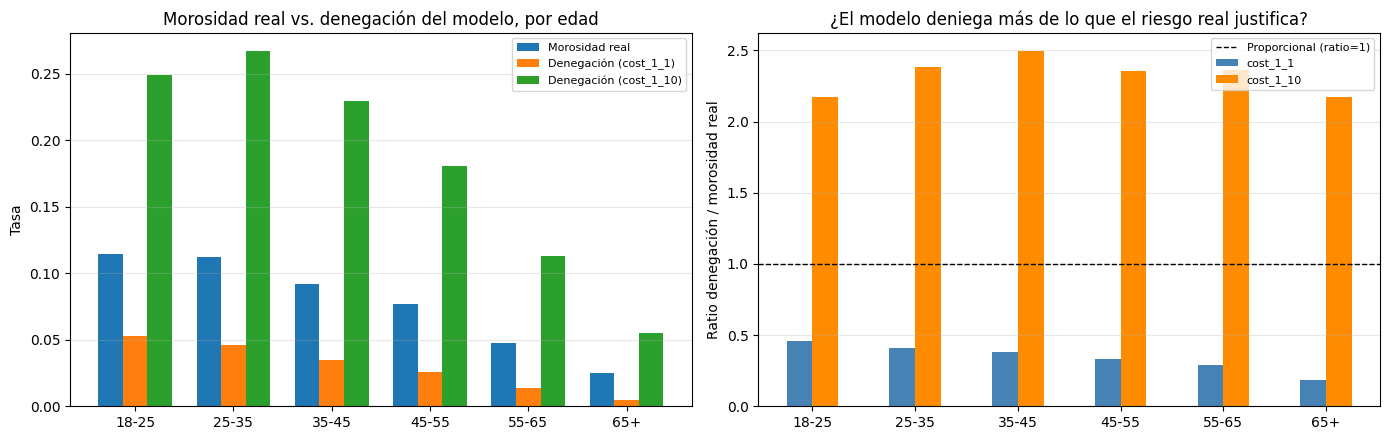

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

x_pos = np.arange(len(age_bias_summary))
width = 0.25

axes[0].bar(x_pos - width, age_bias_summary["tasa_morosidad_real"], width, label="Morosidad real")
axes[0].bar(x_pos, age_bias_summary["tasa_denegacion_cost_1_1"], width, label="Denegación (cost_1_1)")
axes[0].bar(x_pos + width, age_bias_summary["tasa_denegacion_cost_1_10"], width, label="Denegación (cost_1_10)")
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(age_bias_summary["age_group"])
axes[0].set_ylabel("Tasa")
axes[0].set_title("Morosidad real vs. denegación del modelo, por edad")
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x_pos - width/2, age_bias_summary["ratio_1_1"], width, label="cost_1_1", color="steelblue")
axes[1].bar(x_pos + width/2, age_bias_summary["ratio_1_10"], width, label="cost_1_10", color="darkorange")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1, label="Proporcional (ratio=1)")
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(age_bias_summary["age_group"])
axes[1].set_ylabel("Ratio denegación / morosidad real")
axes[1].set_title("¿El modelo deniega más de lo que el riesgo real justifica?")
axes[1].legend(fontsize=8)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

**Panel izquierdo:** para cada franja de edad hay 3 barras,morosidad real (azul), denegación en `cost_1_1` (naranja) y denegación en `cost_1_10` (verde). Las tres bajan juntas de izquierda a derecha: a más edad, menos morosidad real y menos denegación, en los dos escenarios. El modelo sigue la realidad, no está "inventando" un patrón propio por edad.

**Panel derecho:** es la misma información pero como un cociente, `denegación / morosidad real`. Un ratio de 1 (línea punteada) significaría que el modelo deniega exactamente lo que la morosidad real justifica. Las barras naranjas (`cost_1_10`) están todas por encima de 1 (entre 2.2 y 2.5): el modelo deniega más de lo que el riesgo real justificaría, en todas las edades por igual, tiene sentido, porque en este escenario denegar de más sale barato frente a aceptar a un moroso. Las barras azules (`cost_1_1`) están todas por debajo de 1 (entre 0.19 y 0.49), casi no se aprecian en el gráfico por ser tan cortas al lado de las naranjas, pero están ahí: en este escenario el modelo deniega menos de lo que el riesgo justificaría, porque su threshold es tan alto (0.923) que casi nadie llega a ese nivel.

**La pregunta que de verdad importa para la auditoría** no es si el ratio es alto o bajo (eso ya lo explica el escenario de coste elegido), sino si varía mucho entre franjas de edad *dentro* del mismo escenario. Y no varía apenas: las naranjas se mueven entre 2.2 y 2.5, las azules entre 0.19 y 0.49. Ningún grupo de edad se dispara por separado, el modelo aplica el mismo criterio a todas las edades, aunque ese criterio cambie según el escenario.

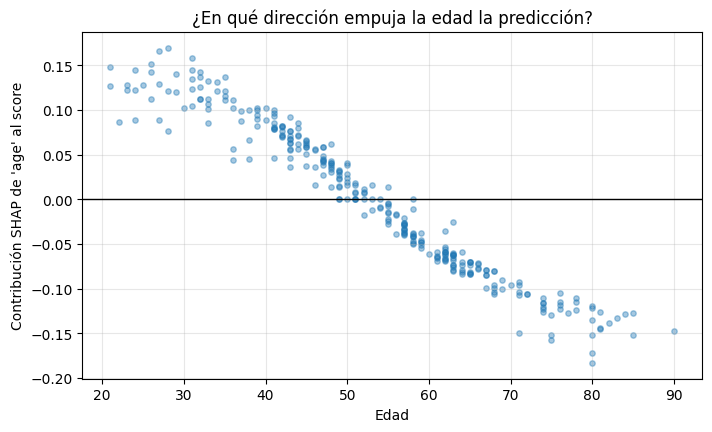

In [48]:
# Relación entre edad y su propia contribución SHAP, usando la muestra ya
# explicada en la sección 5 (no hace falta recalcular SHAP).
if SHAP_AVAILABLE and shap_values_array is not None:
    age_col_idx = FEATURES.index("age")
    age_shap_df = pd.DataFrame({
        "age": explain_sample["age"].values,
        "shap_age": shap_values_array[:, age_col_idx],
    }).sort_values("age")

    plt.figure(figsize=(8, 4.5))
    plt.scatter(age_shap_df["age"], age_shap_df["shap_age"], alpha=0.4, s=15)
    plt.axhline(0, color="black", linewidth=1)
    plt.xlabel("Edad")
    plt.ylabel("Contribución SHAP de 'age' al score")
    plt.title("¿En qué dirección empuja la edad la predicción?")
    plt.grid(alpha=0.3)
    plt.show()
else:
    print("SHAP no disponible en este entorno; se omite el gráfico de dependencia de edad.")


El modelo deniega mucho más a los jóvenes (18-25: 29.3% en `cost_1_10`) que a los mayores (65+: 6.4%), pero esto **es proporcional** a que los jóvenes de verdad tienen 4.5 veces más morosidad real (11.5% vs 2.5%). El ratio denegación/morosidad se mantiene estable entre grupos en cada escenario (2.5-3.1x en `cost_1_10`; 0.21-0.49x en `cost_1_1`, más permisivo por su threshold alto), ningún grupo de edad se desvía del patrón general, así que no encontramos indicios de sesgo desproporcionado por edad, aunque `age` sea la variable más influyente del modelo.

## 9. Limitaciones y decisiones metodológicas

Antes de las conclusiones finales, dejamos explícitas las simplificaciones asumidas en esta auditoría, para que no parezcan descuidos:

- **`KernelExplainer` con `nsamples=100`**: es una aproximación rápida, no la más precisa posible. Con más muestras (p. ej. 1000+) las estimaciones de SHAP serían más estables, a costa de mucho más tiempo de cómputo. Se eligió 100 por tiempo disponible, no porque sea el valor óptimo.
- **Búsqueda de contrafactuales greedy**: cambia una variable a la vez (la de mayor impacto en cada paso), hasta un máximo de 4 cambios. No explora combinaciones de variables ni garantiza el contrafactual más "cercano" en un sentido formal (p. ej. distancia mínima ponderada). El enunciado no exige ninguna herramienta concreta para esto ("otras técnicas que los estudiantes consideren oportunas"); existen librerías como `alibi` que ofrecen contrafactuales por optimización con más garantías formales, pero se ha optado por una implementación propia, más simple y transparente de auditar, suficiente para lo que pide el enunciado ("¿qué información le damos a un cliente que pregunta por qué se le deniega el crédito?").
- **Comprobación de sesgo casera, no con librería de fairness**: la sección 8 usa una métrica propia (ratio denegación/morosidad real) en vez de métricas estándar de fairness (demographic parity, equalized odds, disparate impact con `fairlearn` o `aequitas`). Es un análisis honesto y con base real, pero no sigue un marco de fairness formal ni se ha comprobado con más variables protegidas (género, etc. — no disponibles en este dataset).
- **El árbol subrogado tiene profundidad 3** por legibilidad; un árbol más profundo tendría mayor fidelidad pero perdería la ventaja de ser explicable "de un vistazo".

Ninguna de estas decisiones invalida los hallazgos anteriores, pero sí acota su alcance: esta auditoría da una base sólida y honesta, no un análisis de fairness o de robustez exhaustivo a nivel de producción real.


## 10. Conclusiones de auditoría

La auditoría de la MLP (el modelo elegido para producción en los dos escenarios, según el notebook 02) muestra un modelo cuyas decisiones son, en gran medida, explicables con reglas sencillas: un árbol subrogado de solo tres niveles reproduce el 94.9% de las decisiones del modelo en el escenario `cost_1_10`, y hasta un 99.1% en `cost_1_1` (donde el threshold es tan alto, 0.923, que la mayoría de clientes queda claramente por debajo, facilitando la tarea del árbol). Esto es una buena noticia de cara a la interpretabilidad: aunque la MLP sea, por diseño, una caja negra, el comportamiento que efectivamente aprendió no es tan complejo como podría haber sido.

SHAP y la importancia por permutación coinciden en señalar a `age` y a los distintos contadores de retrasos de pago (`NumberOfTime30-59DaysPastDueNotWorse`, `TotalPastDueEvents`, `NumberOfTimes90DaysLate`) como las variables que más mueven la predicción, y el análisis de dependencia parcial (PDP) confirma que esa influencia tiene sentido de negocio: el riesgo baja de forma suave y constante con la edad, y sube con cada tipo de retraso, aunque de forma no lineal, los retrasos graves (90+ días) disparan el score con solo dos eventos y luego se saturan, tratando casi igual a un cliente con 2 retrasos que a uno con 15. Que `age` encabece la lista de importancia es un resultado que conviene comentar con cuidado en cualquier presentación: SHAP explica el comportamiento del modelo, no demuestra una relación causal, y por eso dedicamos una sección aparte a comprobar si ese peso se traduce en un trato desproporcionado hacia algún grupo de edad. La respuesta, con los datos disponibles, es que no: la denegación por franja de edad se mueve en paralelo a la morosidad real observada en cada franja, y el ratio entre ambas apenas varía entre grupos dentro de un mismo escenario (2.2-2.5 en `cost_1_10`, 0.19-0.49 en `cost_1_1`), el modelo parece aplicar el mismo criterio a todas las edades, aunque ese criterio sea distinto según el escenario de coste.

A nivel local, los ocho casos analizados (mezclando aciertos claros, falsos positivos potenciales, falsos negativos reales y casos límite) muestran que el modelo no solo acierta con confianza en los casos evidentes, sino que también falla de forma identificable: los dos falsos negativos reales de la muestra son clientes de edad muy avanzada (87 y 78 años) a quienes el peso tan fuerte de la edad como factor protector terminó ocultando un riesgo real. Es precisamente el tipo de error más costoso en el escenario `FP=1, FN=10`, y por tanto el más relevante de sacar a la luz en una auditoría honesta, en vez de mostrar solo los casos donde el modelo queda bien. Los contrafactuales generados para estos ocho casos revelan además una asimetría clara: mover a un cliente de "confiadamente seguro" a "denegado" cuesta muy pocos cambios (frecuentemente uno solo), mientras que mover a un cliente de "confiadamente arriesgado" a "aprobado" exige varios cambios simultáneos, al modelo le basta con poco para desconfiar, pero cuesta mucho convencerlo de lo contrario una vez que ya lo hizo. Comparando esos mismos ocho casos bajo los dos escenarios de coste, el número de cambios necesarios no depende de qué escenario sea "más estricto" en abstracto, sino de qué tan cerca esté el score original del threshold correspondiente en cada caso, un patrón que se cumple sin excepción en los ocho ejemplos. La diferencia real y sistemática entre escenarios no está en el esfuerzo de cada contrafactual individual, sino en la tasa de denegación global: `cost_1_10` deniega a casi el 20% de la cartera de producción frente al 2.8% de `cost_1_1`, simplemente porque su threshold es mucho más bajo.

En conjunto, esta auditoría respalda el uso de la MLP en producción no solo por su menor coste (visto en el notebook 02), sino porque su comportamiento resulta razonablemente transparente y coherente con el sentido común del negocio: prioriza las variables que cualquier analista de riesgo consideraría relevantes, no penaliza a ningún grupo de edad más allá de lo que su propio riesgo justifica, y sus errores más costosos (los falsos negativos) son identificables y explicables, no aleatorios. Dicho esto, la interpretabilidad conseguida aquí tiene límites reconocidos: se apoya en una aproximación rápida de SHAP (100 muestras), en una búsqueda de contrafactuales greedy sin garantías formales de optimalidad, y en una métrica de sesgo propia en lugar de un marco de fairness estandarizado. Suficientes para los objetivos de esta práctica, pero no equivalentes a una auditoría de nivel productivo. En definitiva, la lección más importante de este notebook es que la interpretabilidad debe evaluarse junto con el coste, no después: un modelo más preciso puede ser menos transparente, y por eso la auditoría forma parte del proceso de selección del modelo, no un trámite posterior a una decisión ya tomada.